# Wczesna Detekcja Ryzyka Udarowego: Modelowanie ML z Wykorzystaniem Explainable AI (XAI), XGBoost
 * Autor: Aleksander Śmiałowski 
 * Cel: Projekt Portfolio (Data Science / Machine Learning)
 * Zbiór danych: Stroke Prediction Dataset (fedesoriano)

* Wprowadzenie 
- Udar mózgu jest jedną z głównych przyczyn zgonów i niepełnosprawności na świecie. Z perspektywy medycznej i farmaceutycznej, kluczowym wyzwaniem nie jest tylko leczenie skutków, ale przede wszystkim wczesna identyfikacja pacjentów wysokiego ryzyka. Pozwala to na wdrożenie działań prewencyjnych (leczenie nadciśnienia, zmiana stylu życia, farmakoterapia przeciwzakrzepowa).

 * Główne wyzwania projektu:
 - Niezbalansowane dane (Imbalanced Data): Przypadki udaru stanowią zaledwie ok. 4.8% zbioru.
 - Konsekwencje błędów (Cost of Error): W medycynie koszt False Negative (niezdiagnozowanie chorego) jest znacznie wyższy niż koszt False Positive (niepotrzebne badania kontrolne).
 - Interpretowalność (Black Box Problem): Model w medycynie musi być wyjaśnialny zdrowotnie/biologicznie. 
 - Wyniki: Priorytetem dla mnie będzie Recall oraz ROC AUC

* Na czym się skupię ? 
- Advanced Feature Engineering : Zamiast polegać wyłącznie na surowych danych, mam w planach stworzyć  nowe zmienne oparte na wiedzy medycznej (np. interakcje wieku z glukozą, wskaźniki chorób współistniejących)
- Strategia dla Danych Niezbalansowanych : Zamiast sztucznego generowania danych przez(SMOTE) użyje mechanizmu ważenia klas (scale_pos_weight)
- OPTUNA: zastąpie klasycznego Grid Searcha Optuna w celu efektywnego dostrojenia hiperparametrów modelu XGBoost.
- Explainable AI (SHAP): Wykorzystam SHAP w celu sprawdzenia czy model podejmuję decyzję na podstawię logicznych przesłanek medycznych. 

* Lista rzeczy znajdujących się w projekcie 
- Importy
- Pobranie oraz przegląd danych 
- EDA na brudnych danych 
-  Data Cleaning, Preprocesing, Feature Enginering
- Tuning Hiperparametrów (OPTUNA)
-  Model XGBoost
- Wyniki 
- XAI (SHAP)
- Symulacja diagnozy jednego pacjenta (Waterfall PLOT)
- Raport Końcowy 


# IMPORTY 

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import xgboost as xgb
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, make_scorer, recall_score, 
import time
import shap
from sklearn.impute import SimpleImputer
import optuna


c:\Users\PC\Desktop\MED_PROJ\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# POBRANIE DATA SETU 
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1


# OTWARCIE I PRZEGLĄD DATA SETU 

In [3]:

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

try:
    df = pd.read_csv('healthcare-dataset-stroke-data.csv')
    print("Dane załadowane pomyślnie!")
except FileNotFoundError:
    print("Błąd: Nie znaleziono pliku csv. Sprawdź ścieżkę!")


Dane załadowane pomyślnie!


In [4]:
display(df.head())

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB
None


In [6]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [7]:
stroke_counts = df['stroke'].value_counts()
stroke_percentage = df['stroke'].value_counts(normalize=True) * 100

print(f"Liczba udarów (1): {stroke_counts[1]} ({stroke_percentage[1]:.2f}%)")
print(f"Liczba zdrowych (0): {stroke_counts[0]} ({stroke_percentage[0]:.2f}%)")

Liczba udarów (1): 249 (4.87%)
Liczba zdrowych (0): 4861 (95.13%)


# EDA NA BRUDNYCH DANYCH 

In [8]:
print(df.head())

      id  gender   age  hypertension  heart_disease ever_married      work_type Residence_type  avg_glucose_level   bmi   smoking_status  stroke
0   9046    Male  67.0             0              1          Yes        Private          Urban             228.69  36.6  formerly smoked       1
1  51676  Female  61.0             0              0          Yes  Self-employed          Rural             202.21   NaN     never smoked       1
2  31112    Male  80.0             0              1          Yes        Private          Rural             105.92  32.5     never smoked       1
3  60182  Female  49.0             0              0          Yes        Private          Urban             171.23  34.4           smokes       1
4   1665  Female  79.0             1              0          Yes  Self-employed          Rural             174.12  24.0     never smoked       1


C:\Users\PC\AppData\Local\Temp\ipykernel_13508\1363784508.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, palette='coolwarm')
C:\Users\PC\AppData\Local\Temp\ipykernel_13508\1363784508.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, palette='coolwarm')
C:\Users\PC\AppData\Local\Temp\ipykernel_13508\1363784508.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, palette='coolwarm')


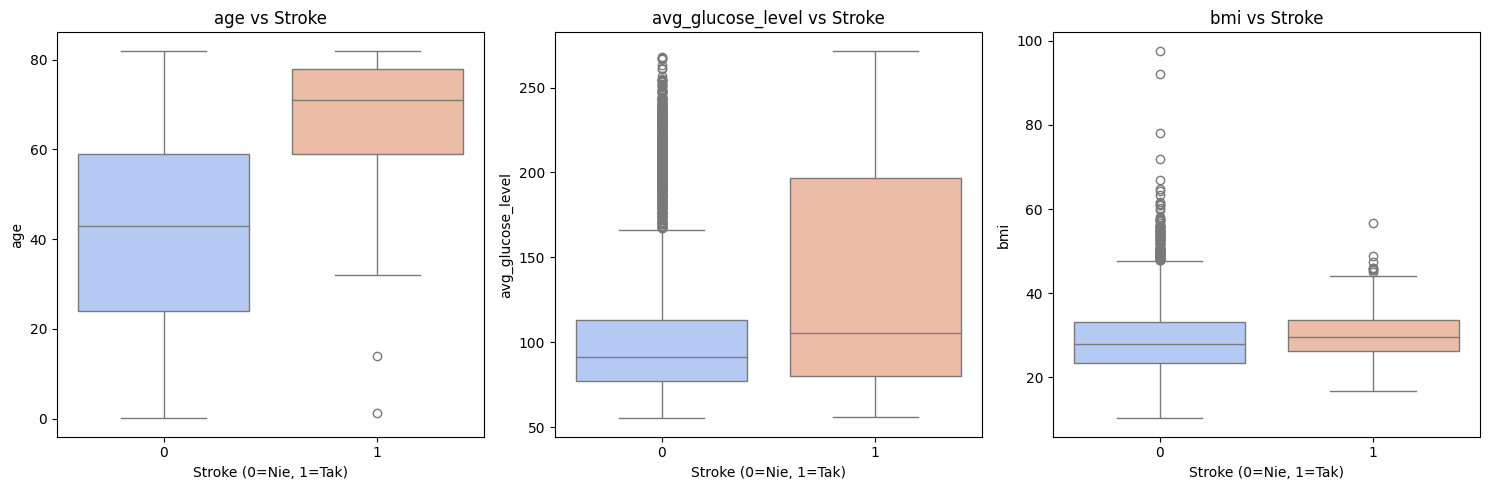

In [9]:
# ANALIZA ZMIENNYCH NUMERYCZNYCH 
'''
BOXPLOTY   
'''
num_cols = ['age', 'avg_glucose_level', 'bmi']

plt.figure(figsize=(15,5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='stroke', y=col, data=df, palette='coolwarm')
    plt.title(f'{col} vs Stroke', fontsize=12)
    plt.xlabel('Stroke (0=Nie, 1=Tak)')

plt.tight_layout()
plt.show()



Zatanawiam się poniewąż w 2 boxplocie (avg_glucose) nie usunę chyba outlierów ponieważ są to zapewne osoby z cukrzycą 

C:\Users\PC\AppData\Local\Temp\ipykernel_13508\3694153624.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['stroke'] == 0]['age'], label='Brak Udaru', shade=True, color='blue', alpha=0.3)
C:\Users\PC\AppData\Local\Temp\ipykernel_13508\3694153624.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['stroke'] == 1]['age'], label='Udar', shade=True, color='red', alpha=0.3)


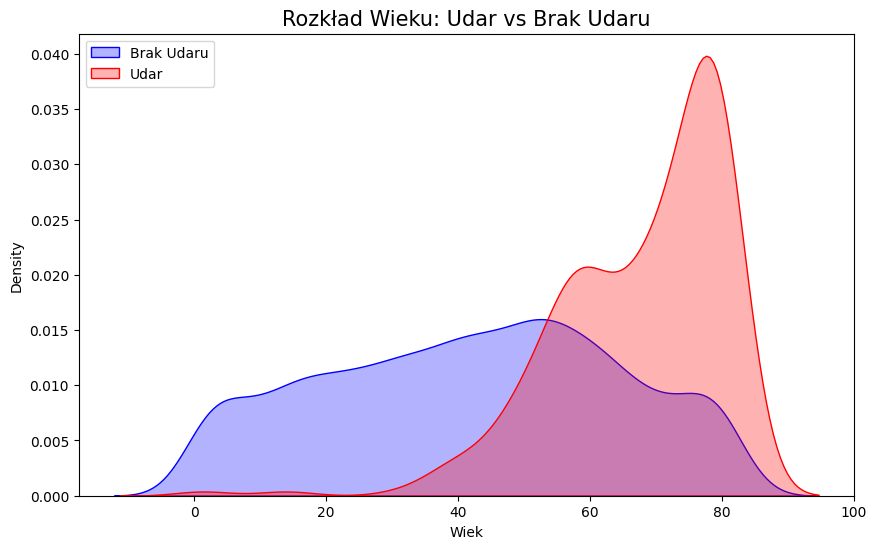

In [10]:
'''
ANALIZA ROZKŁADU (KDE Plot) dla Wieku
'''
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['stroke'] == 0]['age'], label='Brak Udaru', shade=True, color='blue', alpha=0.3)
sns.kdeplot(df[df['stroke'] == 1]['age'], label='Udar', shade=True, color='red', alpha=0.3)
plt.title('Rozkład Wieku: Udar vs Brak Udaru', fontsize=15)
plt.xlabel('Wiek')
plt.legend()
plt.show()

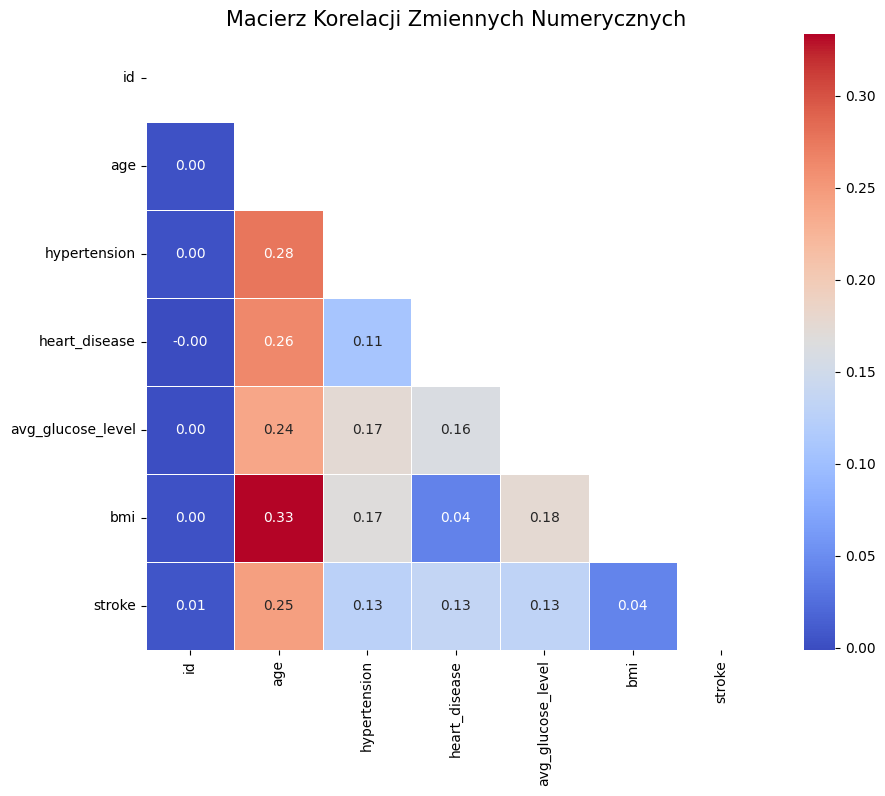

In [11]:
# MACIERZ KORELACJI  
# tylko dla kolumn numerycznych 
corr_matrix = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz Korelacji Zmiennych Numerycznych', fontsize=15)
plt.show()


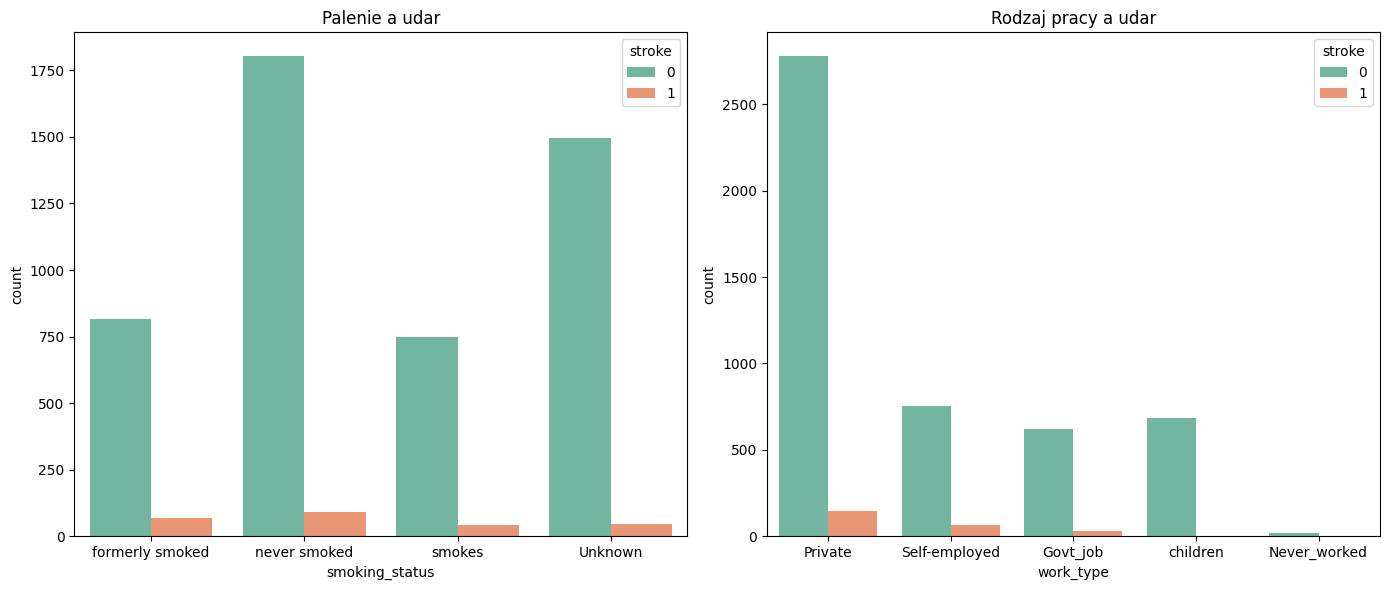

In [12]:

# PALENIE PRACA I UDAR 
plt.figure(figsize=(14, 6))

# 1 wykres 
plt.subplot(1, 2, 1)
sns.countplot(x='smoking_status', hue='stroke', data=df, palette='Set2')
plt.title('Palenie a udar', fontsize=12)

# 2 wykres

plt.subplot(1, 2, 2)
sns.countplot(x='work_type', hue='stroke', data=df, palette='Set2')
plt.title('Rodzaj pracy a udar', fontsize=12)

plt.tight_layout()
plt.show()



# DATA CLEANING , PREPROCESSING, FEATURE ENGINERING 

In [13]:
print(df.head())


      id  gender   age  hypertension  heart_disease ever_married      work_type Residence_type  avg_glucose_level   bmi   smoking_status  stroke
0   9046    Male  67.0             0              1          Yes        Private          Urban             228.69  36.6  formerly smoked       1
1  51676  Female  61.0             0              0          Yes  Self-employed          Rural             202.21   NaN     never smoked       1
2  31112    Male  80.0             0              1          Yes        Private          Rural             105.92  32.5     never smoked       1
3  60182  Female  49.0             0              0          Yes        Private          Urban             171.23  34.4           smokes       1
4   1665  Female  79.0             1              0          Yes  Self-employed          Rural             174.12  24.0     never smoked       1


In [14]:
df_processed = df.copy()


# drop id 
df_processed = df_processed.drop(columns=['id'])

# uzupełnienie jednego other w gender 
df_processed['gender'] = df_processed['gender'].replace('Other', 'Male')

# BMI FIX
# Zamiast robić mediany prostej to zrobimy mediane zależna od płci ponieważ kobiety są mniejsze i lżejsze od mężczyzn 
df_processed['bmi'] = df_processed['bmi'].fillna(df_processed.groupby('gender')['bmi'].transform('median'))

# WIEK * POZIOM GLUKOZY
df_processed['age_glucose_interaction'] = df_processed['age'] * df_processed['avg_glucose_level']
# WIEK *BMI 
df_processed['age_bmi_interaction'] = df_processed['age'] * df_processed['bmi']
# high risk
df_processed['comorbidity_score'] = df_processed['hypertension'] + df_processed['heart_disease']
# KATEGORYZACJA GLUKOZY ( musiałem doczytać )
df_processed['glucose_category'] = pd.cut(df_processed['avg_glucose_level'], 
                                          bins=[-1, 140, 200, 1000], 
                                          labels=[0, 1, 2]).astype(int)

# encoding na binarke 
binary_cols = ['ever_married', 'Residence_type', 'gender']
le = LabelEncoder()
for col in binary_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# multiclas --> one hot encoding 
df_processed = pd.get_dummies(df_processed, columns=['work_type', 'smoking_status'], drop_first=True)

print("Kształt danych po preprocessingu:", df_processed.shape)

# zmiana bool na int 1/0 
bool_cols = df_processed.select_dtypes(include=['bool']).columns
df_processed[bool_cols] = df_processed[bool_cols].astype(int)

# sprawdzam czy moje nowe cechy korelują z udarem 
new_features = ['age_glucose_interaction', 'age_bmi_interaction', 'comorbidity_score', 'stroke']
print("\n--- Korelacja nowych cech z Targetem (Stroke) ---")
print(df_processed[new_features].corr()['stroke'].sort_values(ascending=False))

display(df_processed.head())



Kształt danych po preprocessingu: (5110, 20)

--- Korelacja nowych cech z Targetem (Stroke) ---
stroke                     1.000000
age_glucose_interaction    0.246558
age_bmi_interaction        0.212030
comorbidity_score          0.174616
Name: stroke, dtype: float64


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,age_glucose_interaction,age_bmi_interaction,comorbidity_score,glucose_category,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,15322.23,2452.2,1,2,0,1,0,0,1,0,0
1,0,61.0,0,0,1,0,202.21,27.8,1,12334.81,1695.8,0,2,0,0,1,0,0,1,0
2,1,80.0,0,1,1,0,105.92,32.5,1,8473.60,2600.0,1,0,0,1,0,0,0,1,0
3,0,49.0,0,0,1,1,171.23,34.4,1,8390.27,1685.6,0,1,0,1,0,0,0,0,1
4,0,79.0,1,0,1,0,174.12,24.0,1,13755.48,1896.0,1,1,0,0,1,0,0,1,0


# TUNING HIPERPARAMETRÓW (OPTUNA)

In [15]:
X = df_processed.drop(columns=['stroke'])
y = df_processed['stroke']

# Podział stratyfikowany 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# obliczanie scale_pos_weight
ratio = float(np.sum(y_train ==0)) // np.sum(y_train == 1)
print(f"Baza dla scale_pos_weight: {ratio:.2f}")

# OPTUNA
def objective(trial) :

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', ratio * 0.8, ratio * 1.5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),

        'n_jobs' : -1,
        'random_state' : 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }

    model = XGBClassifier(**params)
    
    # walidacja krzyżowa 
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1)

    return scores.mean()

# uruchomienie optuny 
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
print(" Rozpoczynam optymalizację parametrów (Optuna)...")
# wyniki 
print("\nZakończono!")
print(f"Najlepsze osiągnięte AUC (Cross-Validation): {study.best_value:.4f}")
print("\n--- NAJLEPSZE PARAMETRY (Do skopiowania do modelu końcowego) ---")
best_params = study.best_params
for key, value in best_params.items():
    print(f"'{key}': {value},")





Baza dla scale_pos_weight: 19.00


c:\Users\PC\Desktop\MED_PROJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:07:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\PC\Desktop\MED_PROJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:07:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\PC\Desktop\MED_PROJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:07:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\PC\Desktop\MED_PROJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:07:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_en

 Rozpoczynam optymalizację parametrów (Optuna)...

Zakończono!
Najlepsze osiągnięte AUC (Cross-Validation): 0.8423

--- NAJLEPSZE PARAMETRY (Do skopiowania do modelu końcowego) ---
'n_estimators': 182,
'max_depth': 3,
'learning_rate': 0.03952783720147311,
'subsample': 0.7291044571588553,
'colsample_bytree': 0.9578530351768876,
'scale_pos_weight': 20.20904588945944,
'min_child_weight': 6,


# MODEL

In [16]:
final_params = study.best_params
final_params['random_state'] = 42
final_params['n_jobs'] = -1
final_params['use_label_encoder'] = False
final_params['eval_metric'] = 'logloss'
print(f"Finalne parametry modelu:\n{final_params}")
# Budowa i trening Finalnego Modelu
xgb_final = XGBClassifier(**final_params)

print("\nTrwa trenowanie modelu finalnego...")
xgb_final.fit(X_train, y_train)

# Predykcje na zbiorze testowym
y_pred = xgb_final.predict(X_test)
y_pred_proba = xgb_final.predict_proba(X_test)[:, 1]



Finalne parametry modelu:
{'n_estimators': 182, 'max_depth': 3, 'learning_rate': 0.03952783720147311, 'subsample': 0.7291044571588553, 'colsample_bytree': 0.9578530351768876, 'scale_pos_weight': 20.20904588945944, 'min_child_weight': 6, 'random_state': 42, 'n_jobs': -1, 'use_label_encoder': False, 'eval_metric': 'logloss'}

Trwa trenowanie modelu finalnego...


c:\Users\PC\Desktop\MED_PROJ\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:08:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# WYNIKI 
 -  ROC AUC
 - CONFUSION MATRIX 



--- CLASSIFICATION REPORT (FINAL) ---
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       972
           1       0.15      0.80      0.25        50

    accuracy                           0.76      1022
   macro avg       0.57      0.78      0.55      1022
weighted avg       0.95      0.76      0.83      1022



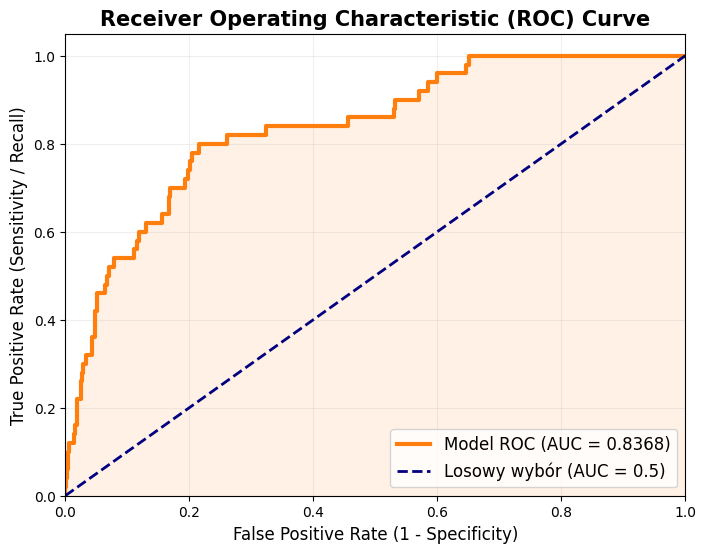

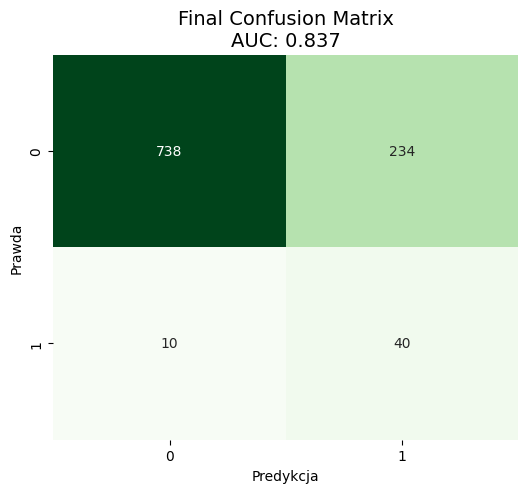

In [17]:
print("\n--- CLASSIFICATION REPORT (FINAL) ---")
print(classification_report(y_test, y_pred))

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#ff7f0e', lw=3, label=f'Model ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Losowy wybór (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.2)
plt.fill_between(fpr, tpr, alpha=0.1, color='#ff7f0e')

# Confusion Matrix - Wykres
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title(f'Final Confusion Matrix\nAUC: {roc_auc:.3f}', fontsize=14)
plt.xlabel('Predykcja')
plt.ylabel('Prawda')
plt.show()

# EXPLAINABLE AI (SHAP ANALYSIS)

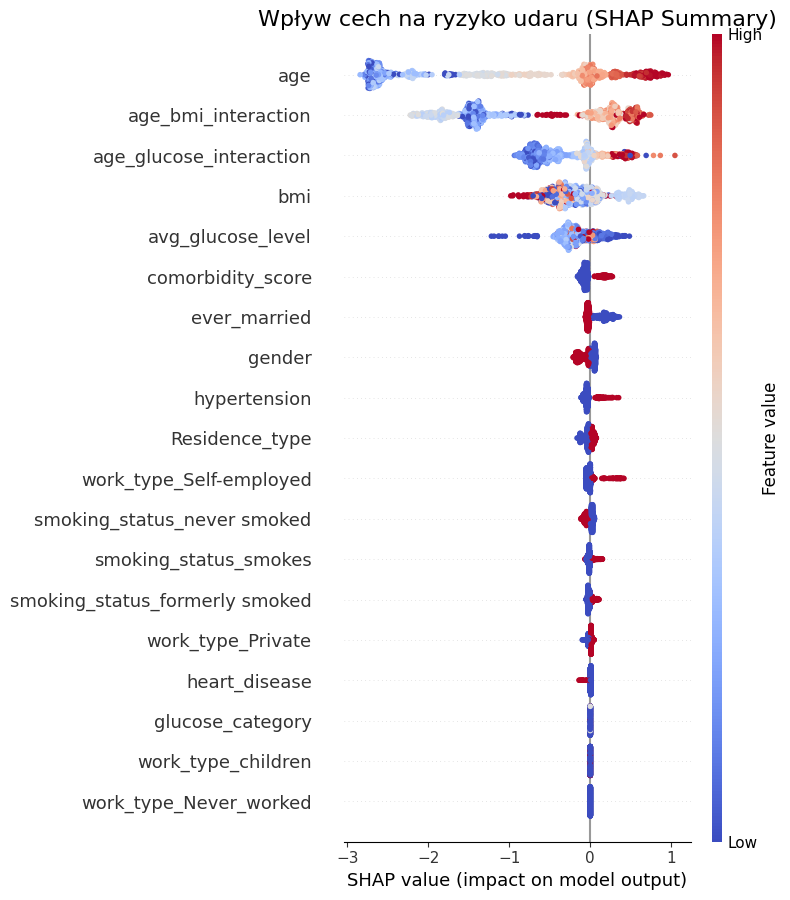

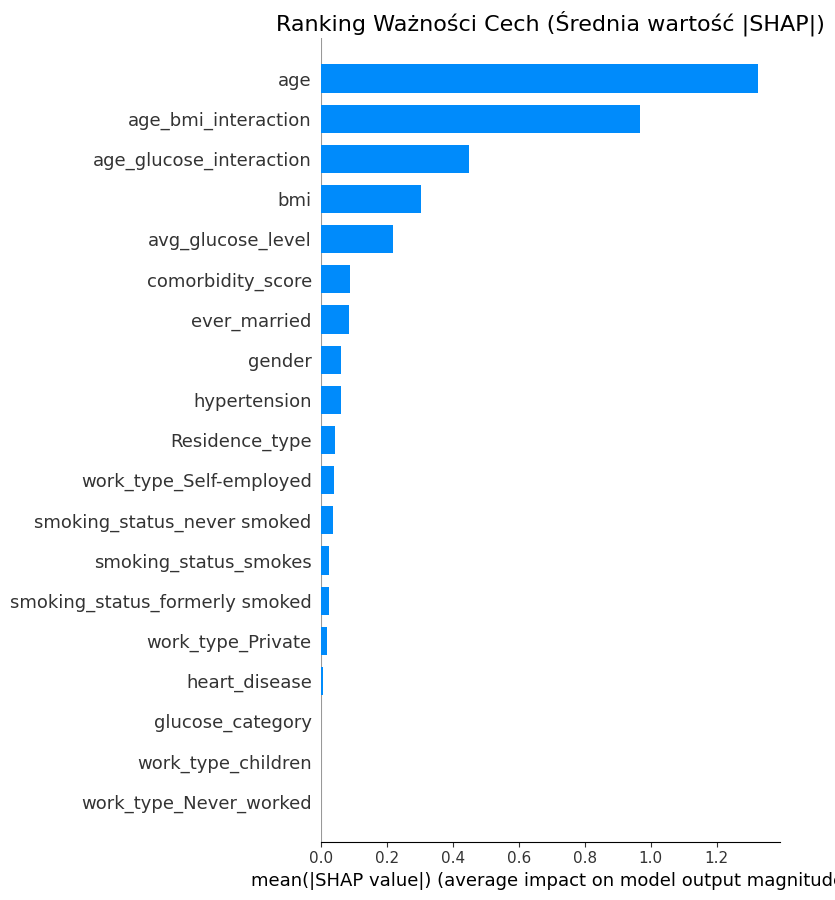

In [18]:
shap.initjs()

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)

# wykres  SUMMARY PLOT
plt.figure(figsize=(12, 10))
plt.title("Wpływ cech na ryzyko udaru (SHAP Summary)", fontsize=16)
shap.summary_plot(shap_values, X_test, show=False, cmap='coolwarm')
plt.tight_layout()
plt.show()

# wykres 2 RANKING
plt.figure(figsize=(10, 8))
plt.title("Ranking Ważności Cech (Średnia wartość |SHAP|)", fontsize=16)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()




# INDYWIDUALNY PRZYPADEK (WATERFALL PLOT)

Analiza przypadku dla pacjenta o indeksie w X_test: 33
Prawdziwa klasa: 1
Predykcja modelu: 1


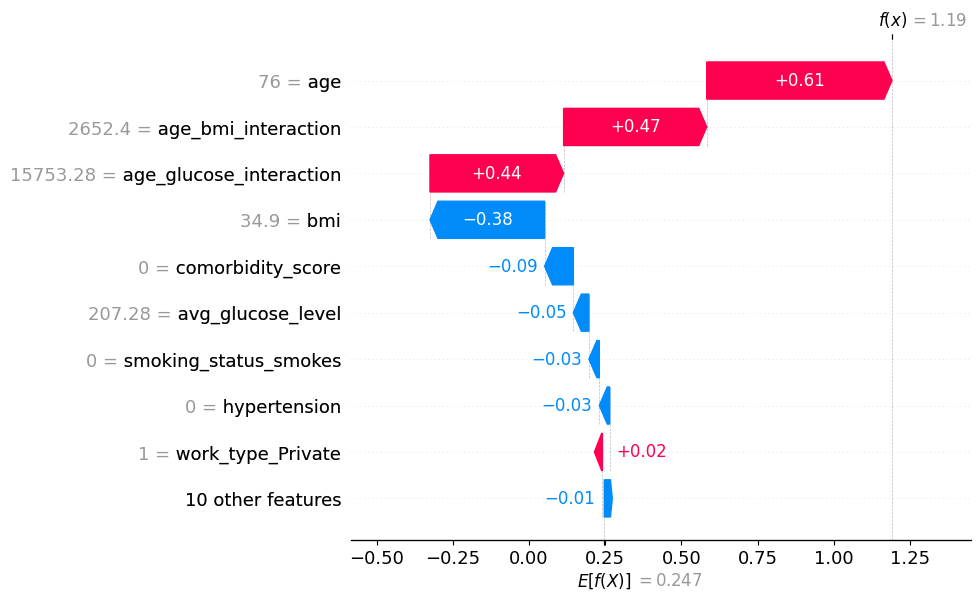

In [19]:
stroke_patients_indices = np.where(y_test == 1)[0]
patient_idx = stroke_patients_indices[0]

print(f"Analiza przypadku dla pacjenta o indeksie w X_test: {patient_idx}")
print(f"Prawdziwa klasa: {y_test.iloc[patient_idx]}")
print(f"Predykcja modelu: {y_pred[patient_idx]}")

plt.figure(figsize=(8, 8))
shap.plots.waterfall(explainer(X_test)[patient_idx], max_display=10)




# RAPORT KOŃCOWY 

 * Skuteczność Diagnostyczna (Performance Summary)
 - Zbudowany model XGBoost osiągnął ROC AUC na poziomie 0.84
 - Wysoki Priorytet Czułości (Recall = 80%): Dzięki zastosowaniu techniki ważenia klas (scale_pos_weight), optymalizacji za pomocą Optuna oraz dzięki inżynierii cech model skutecznie identyfikuje 4 na 5 pacjentów zagrożonych udarem
 - Niska precyzja (15%) jest świadomą decyzją projektową. W kontekście klinicznym oznacza że system generuję duża ilość alarmów dla pacjentów którzy nie są zagrożeni udarem. Aczkolwiek koszt badań profilaktycznych/prewencyjnych jest nieporównywalnie niższy, niż koszt leczenia osoby po udarzę. 

 * Wartość inżynierii Cech 
- Analiza SHAP (Explainable AI) jednoznacznie potwierdziła hipotezę, że ryzyko udaru nie jest sumą prostych czynników, lecz wynikiem ich nieliniowych interakcji.
 - Zmienne stworzone w procesie Feature Engineeringu – age_bmi_interaction ,  age_glucose_interaction praz comorbidity score znalazły się wysoko w analizie SHAP. Dowodzi to temu iż otyłość , wysoki poziom cukru, choroby krązenia lub serca połączone z zaawansowanym wiekiem stają się krytyczne dla powstania udaru 

* Interpretowalność i Zaufanie
- Model nie działa jako "czarna skrzynka". Dzięki implementacji SHAP Waterfall Plots, system jest w stanie wygenerować raport wyjaśniający, dlaczego dany pacjent został zakwalifikowany do grupy ryzyka
- Jest to kluczowy wymóg przy wdrażaniu systemów AI w podmiotach leczniczych (zgodnie z wytycznymi EU AI Act).


